# Notebook 4 - Relatorio Analitico e Decisao

Compara a quantidade comprada real com a quantidade final indicada por cada pipeline two-stage.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "two_stage_common.py").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str((Path("data") / "notebooks").resolve()))

from two_stage_common import list_expected_artifacts, run_comparison_notebook

## Artefatos carregados

In [2]:
artifacts = list_expected_artifacts()
display(artifacts)

,artifact,size_mb
0,01_knn_gradient_boosting_classifier_classifier...,0.149260
1,01_knn_gradient_boosting_regressor_regressor.pkl,0.147413
2,01_knn_knn_classifier_classifier.pkl,61.429702
3,01_knn_knn_regressor_regressor.pkl,15.812942
4,01_knn_xgboost_classifier_classifier.pkl,0.310342
5,01_knn_xgboost_regressor_regressor.pkl,0.371996
6,02_linear_gradient_boosting_classifier_classif...,0.149260
7,02_linear_gradient_boosting_regressor_regresso...,0.147413
8,02_linear_linear_regression_regressor.pkl,0.015795
9,02_linear_logistic_regression_classifier.pkl,0.014765


## Ranking estrategico: compra real vs quantidade indicada

Modelos PKL carregados: 18


,rank_estrategico,notebook,family,pair_key,pipeline,classifier_model,regressor_model,mae_vs_real,rmse_vs_real,bias_medio,...,over_recommendation_rate,under_recommendation_rate,mae_vs_alvo_abt,rmse_vs_alvo_abt,r2_vs_alvo_abt,f1_score,classification_accuracy,target_rmse,target_mae,target_r2
0,1,01_knn,Distancia,knn,Distancia - Knn,KNN Classifier,KNN Regressor,8.584273,85.582878,4.428522,...,0.222302,0.049750,3.861086,57.698752,0.719301,0.869863,0.940243,98.581844,14.787691,0.804910
1,2,01_knn,Distancia,xgboost,Distancia - Xgboost,XGBoost Classifier,XGBoost Regressor,9.739158,98.629272,5.647982,...,0.238027,0.048749,2.412403,33.987747,0.902601,0.947876,0.975268,84.369323,11.155200,0.857107
2,3,02_linear,Linear,xgboost,Linear - Xgboost,XGBoost Classifier,XGBoost Regressor,9.739158,98.629272,5.647982,...,0.238027,0.048749,2.412403,33.987747,0.902601,0.947876,0.975268,84.369323,11.155200,0.857107
3,4,03_tree_ensembles,Arvores,xgboost,Arvores - Xgboost,XGBoost Classifier,XGBoost Regressor,9.739158,98.629272,5.647982,...,0.238027,0.048749,2.412403,33.987747,0.902601,0.947876,0.975268,84.369323,11.155200,0.857107
4,5,03_tree_ensembles,Arvores,random_forest,Arvores - Random Forest,Random Forest Classifier,Random Forest Regressor,9.776944,96.056579,5.699827,...,0.233167,0.048320,2.676283,40.084493,0.864524,0.956151,0.979414,91.799715,12.161770,0.830830
5,6,03_tree_ensembles,Arvores,gradient_boosting,Arvores - Gradient Boosting,Gradient Boosting Classifier,Gradient Boosting Regressor,10.138605,105.766214,6.047516,...,0.234024,0.047462,2.499017,33.180474,0.907173,0.955515,0.979128,70.960787,10.884256,0.898917
6,7,01_knn,Distancia,gradient_boosting,Distancia - Gradient Boosting,Gradient Boosting Classifier,Gradient Boosting Regressor,10.158588,106.415699,6.067498,...,0.234024,0.047462,2.492954,32.934060,0.908547,0.955515,0.979128,70.554901,10.866622,0.900070
7,8,02_linear,Linear,gradient_boosting,Linear - Gradient Boosting,Gradient Boosting Classifier,Gradient Boosting Regressor,10.161691,106.289699,6.070602,...,0.234024,0.047462,2.477440,32.781747,0.909391,0.955515,0.979128,71.221524,10.884353,0.898173
8,9,02_linear,Linear,linear,Linear - Linear,Logistic Regression,Linear Regression,10.186655,101.591771,6.195675,...,0.175983,0.050893,3.829194,44.490860,0.833102,0.864078,0.939957,91.849960,16.470480,0.830644


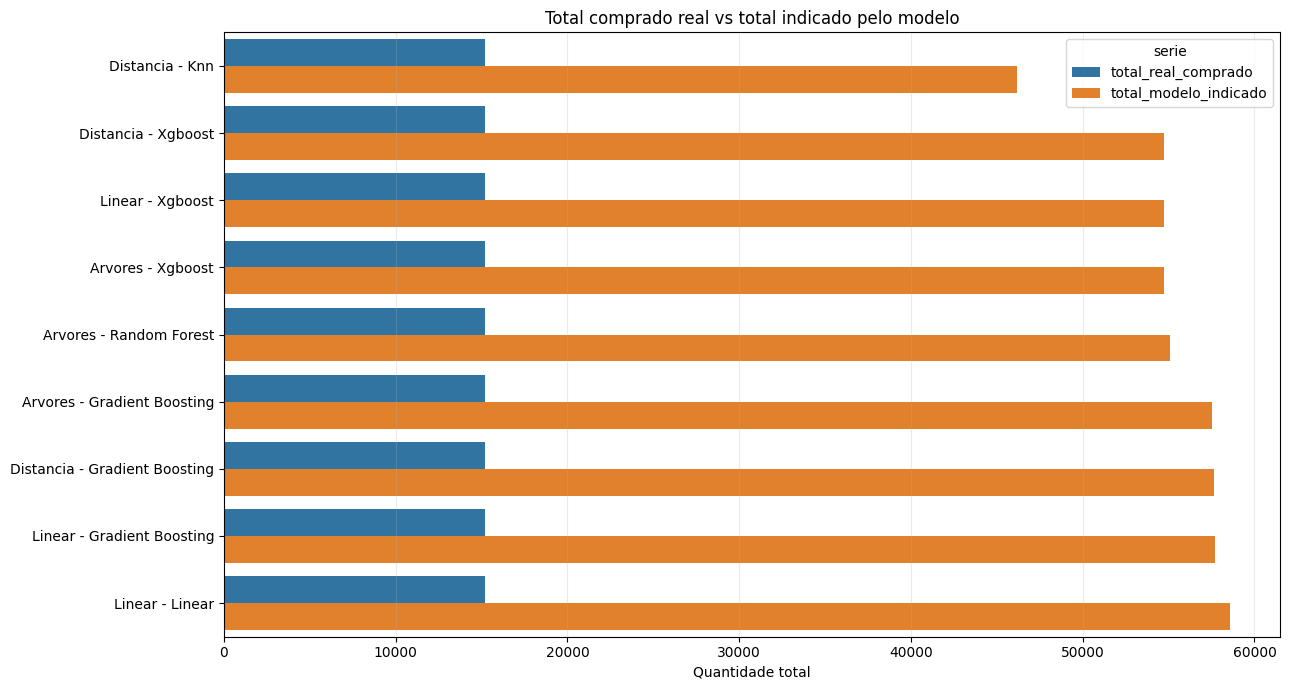

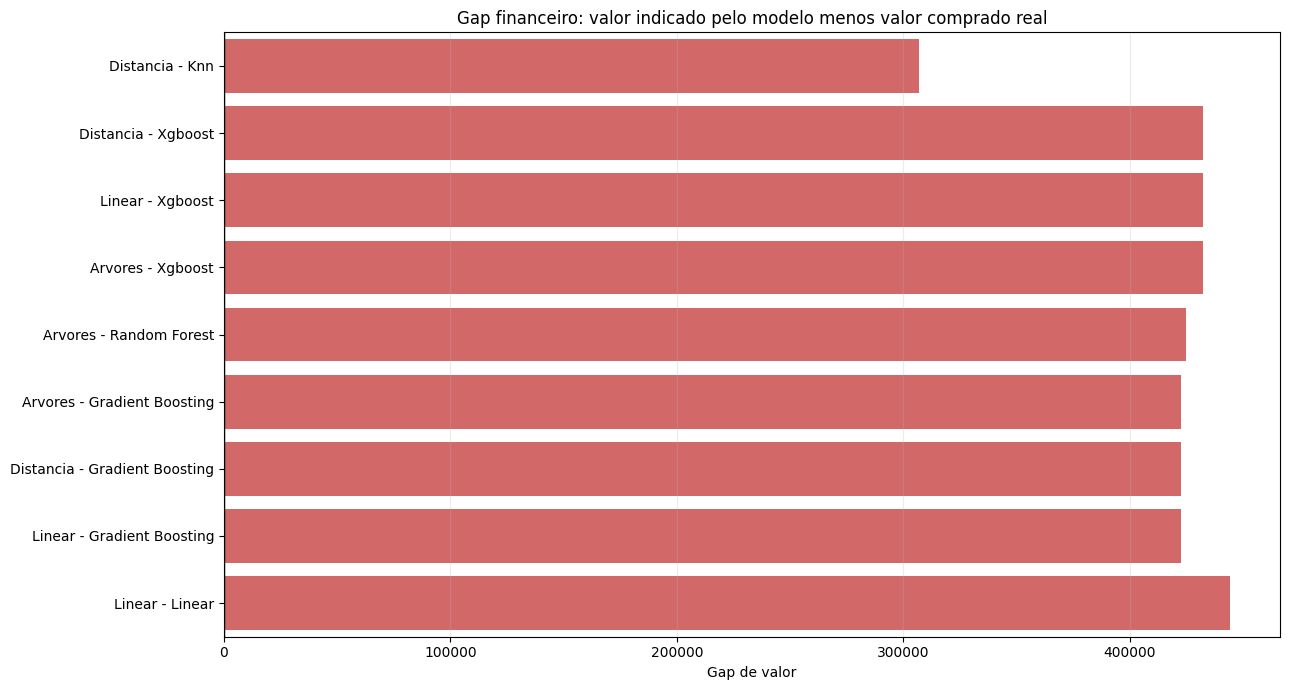

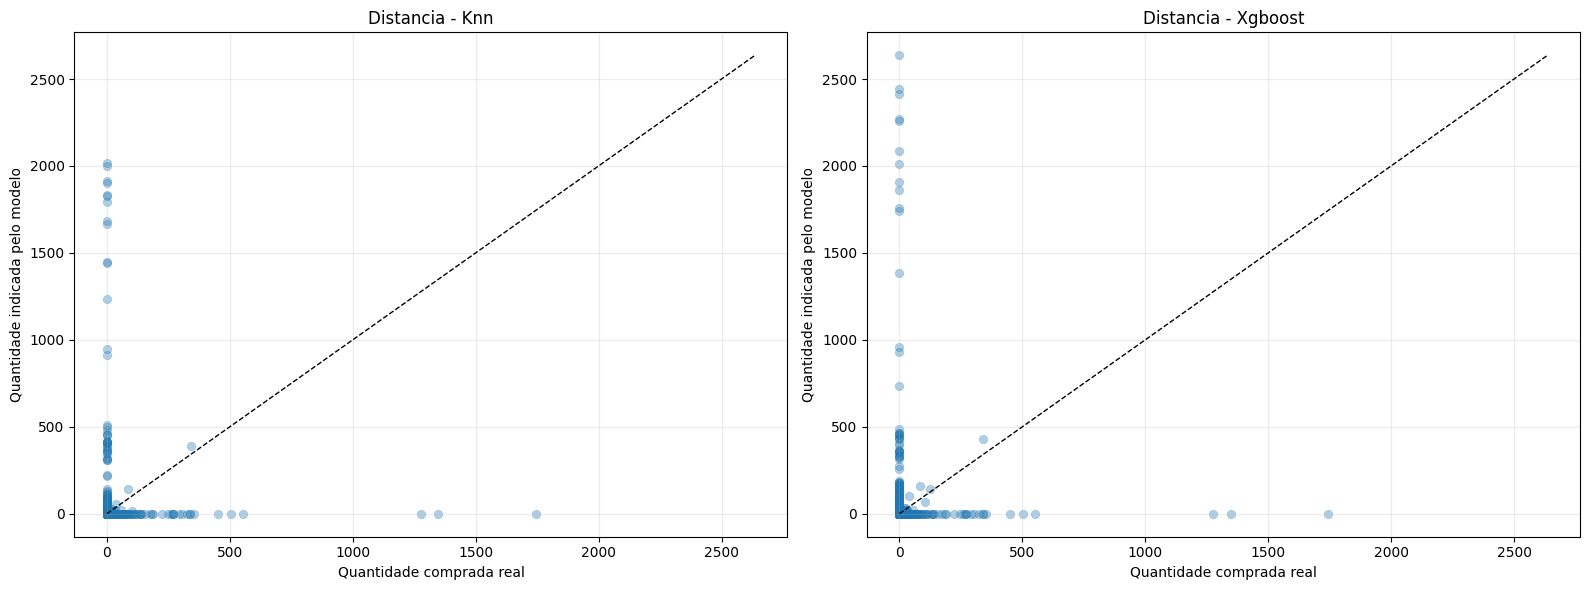

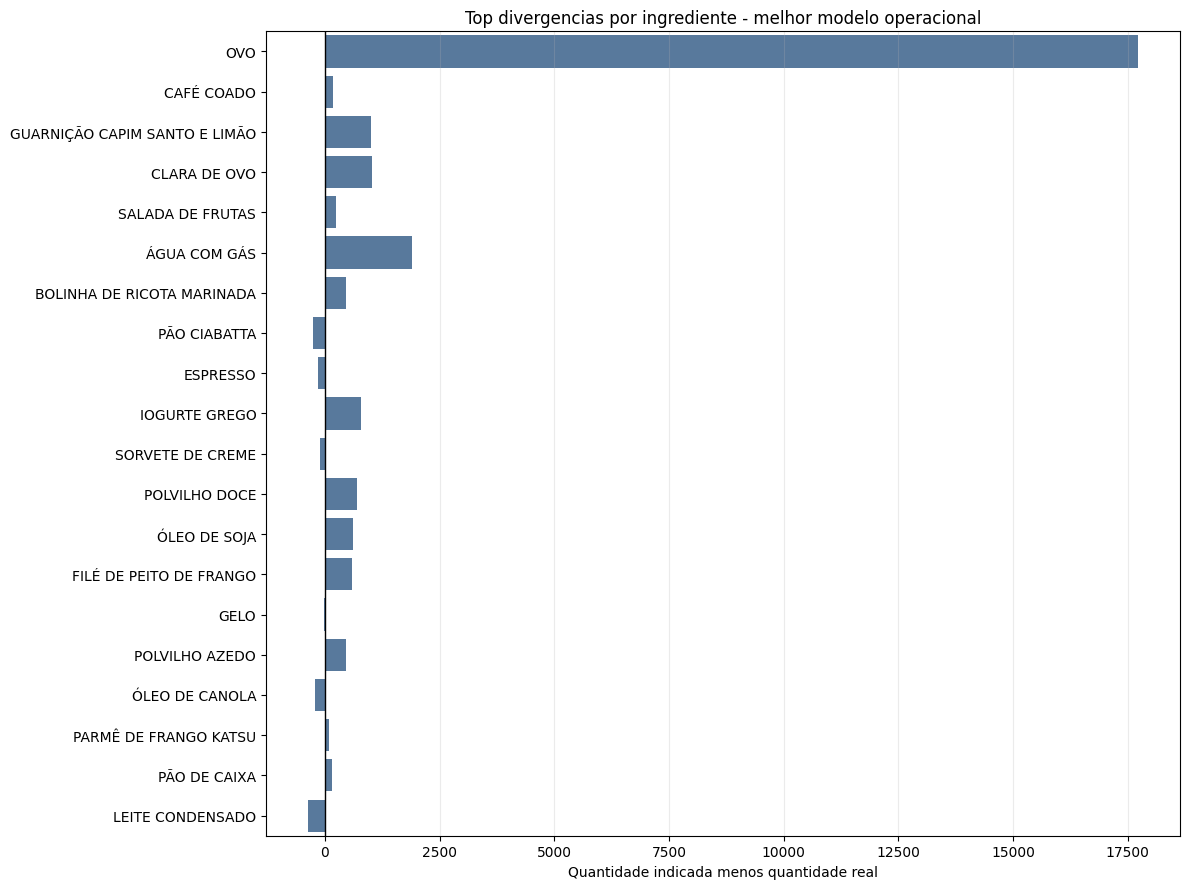

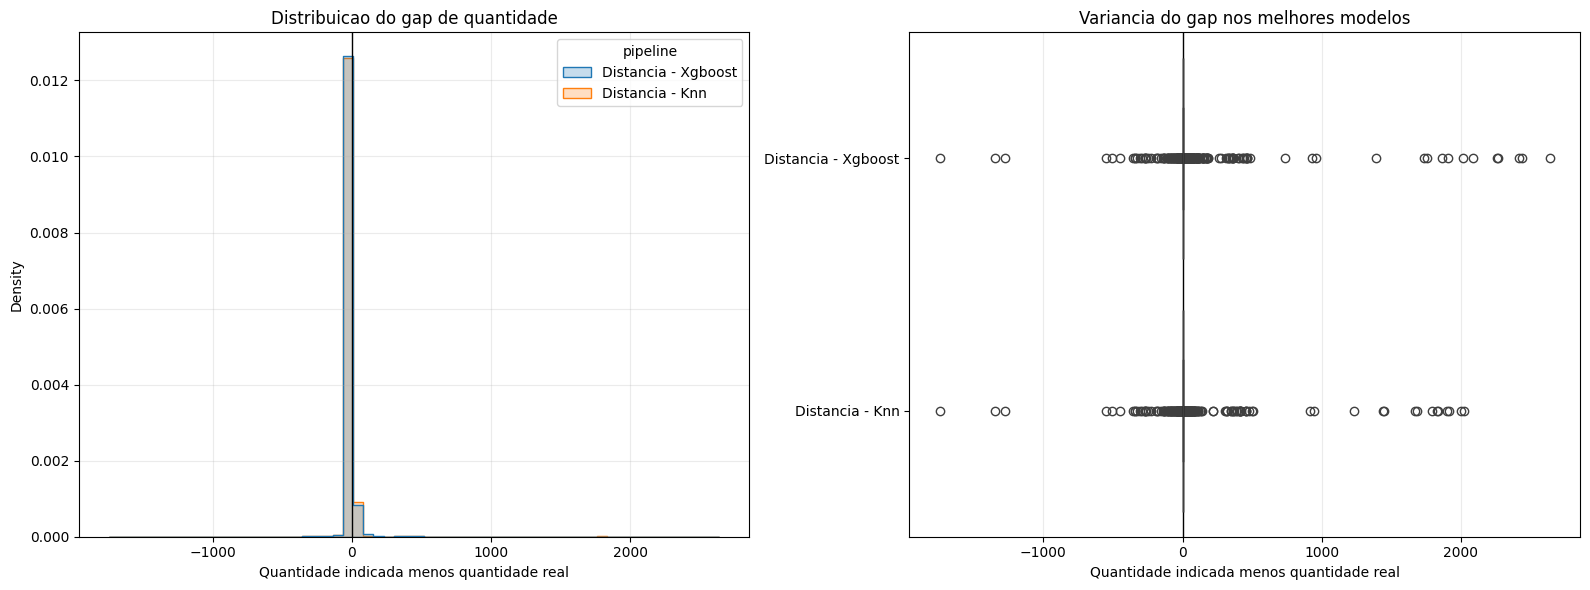

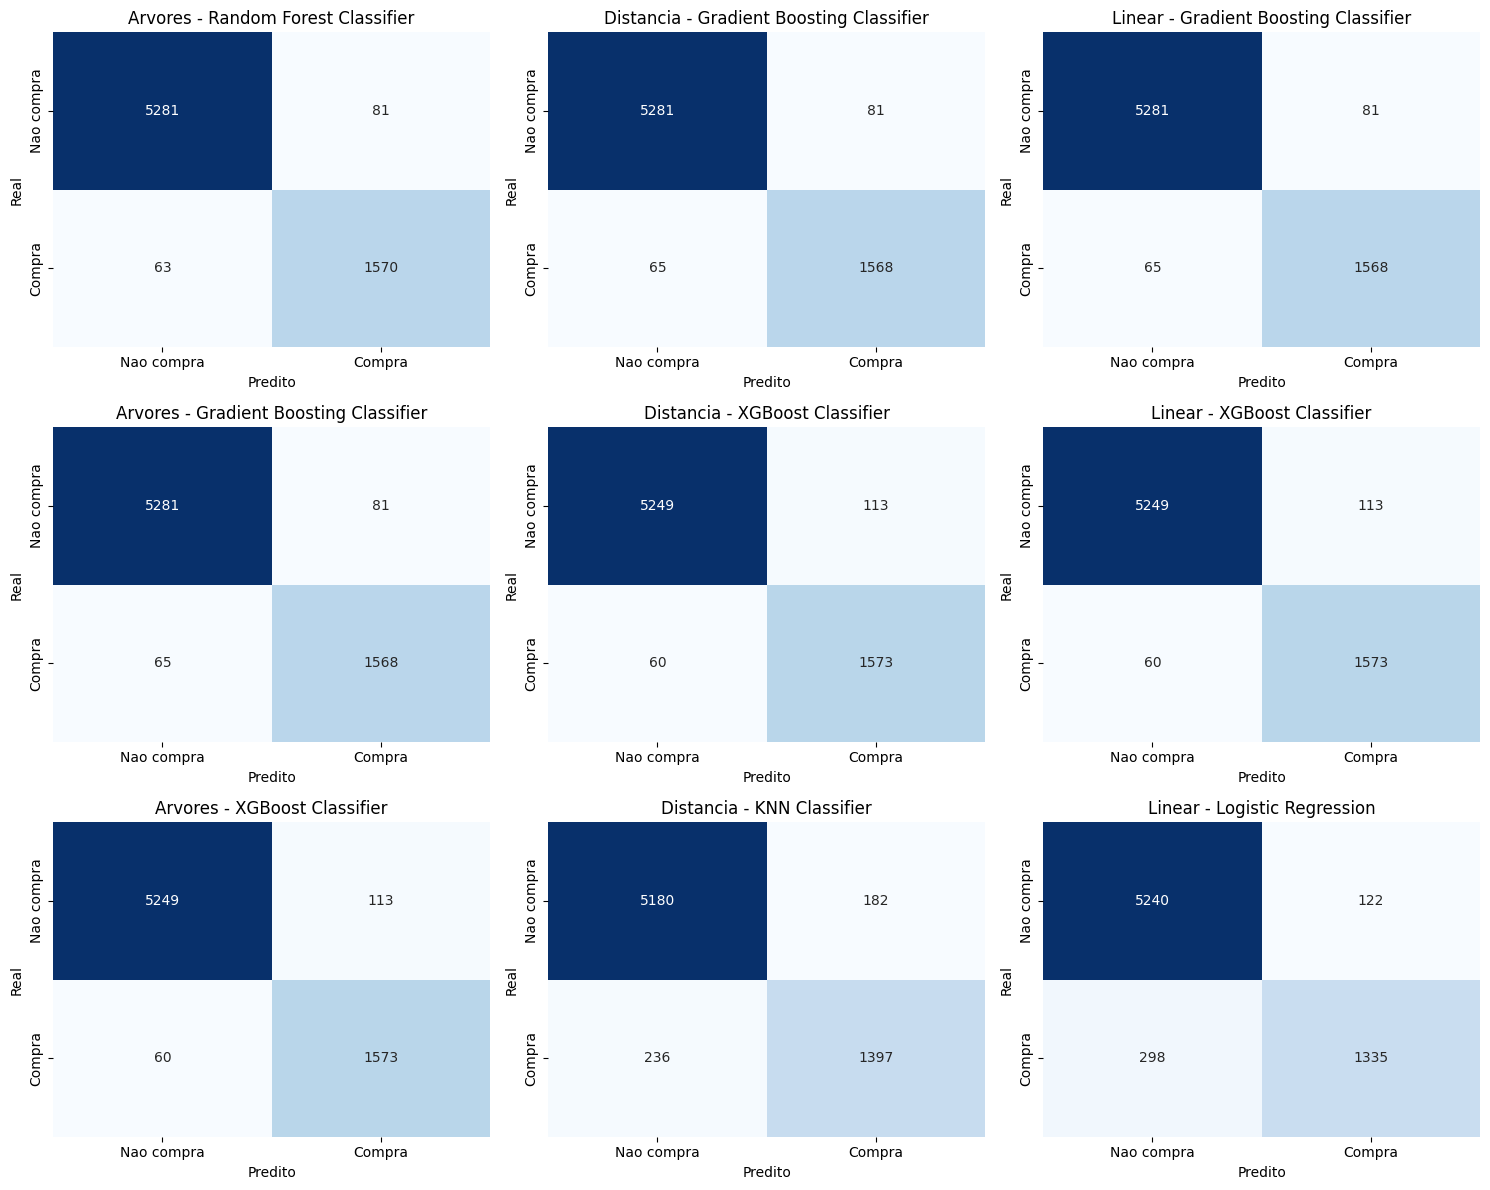

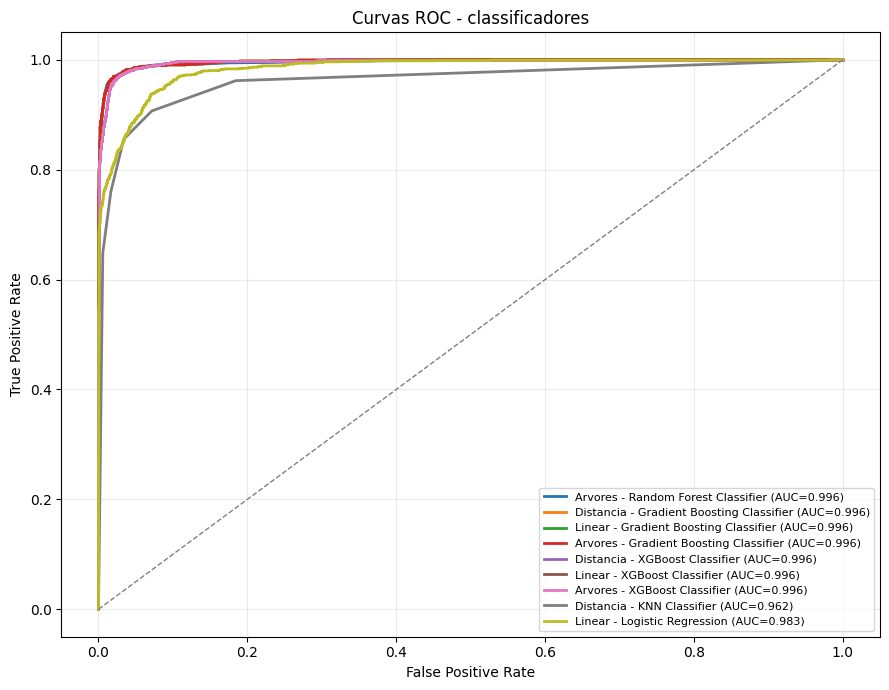

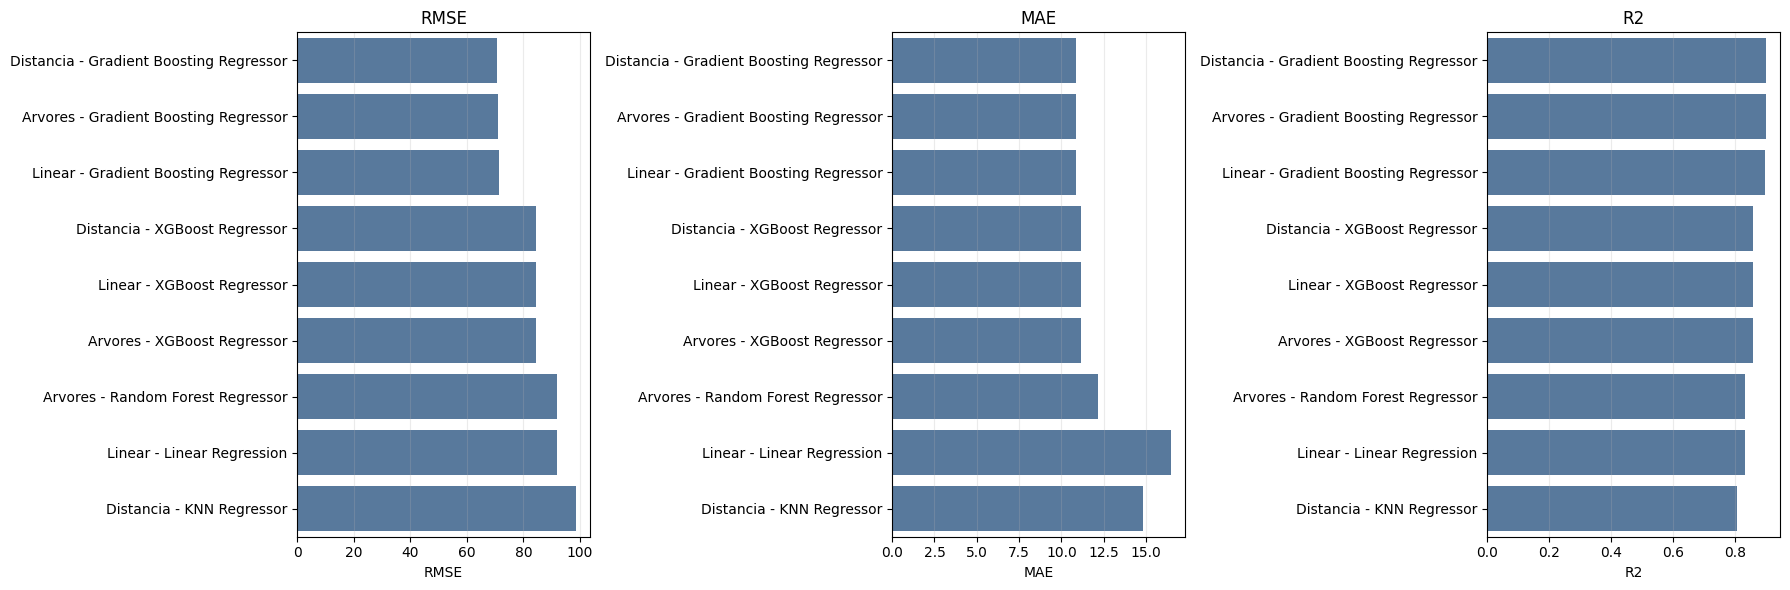

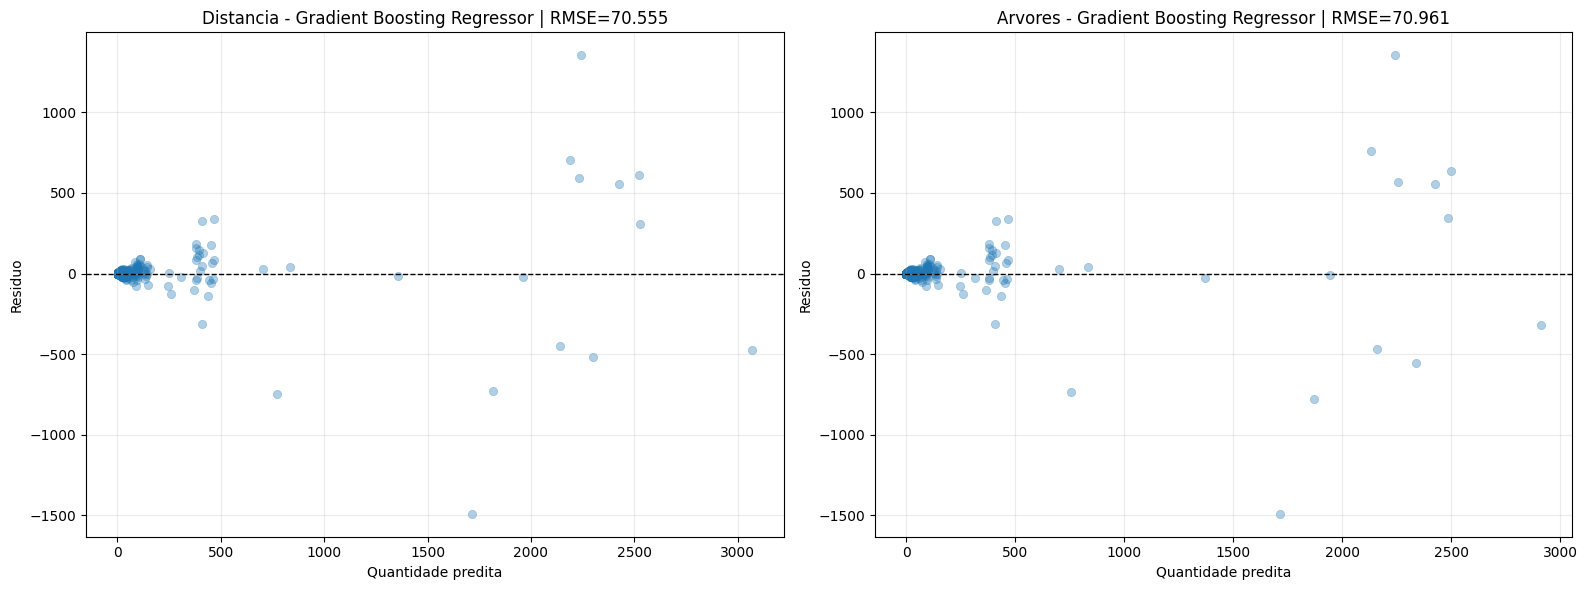

In [3]:
comparison = run_comparison_notebook()

print(f"Modelos PKL carregados: {comparison['models_loaded']}")
display(comparison["operational_metrics"])

## Recomendacoes operacionais detalhadas

In [4]:
display(comparison["operational_recommendations"].head(25))

,pipeline,notebook,family,pair_key,ingredient_id,date,nome_ingrediente,categoria,unidade,qtd_pedida_no_dia_audit,...,regressor_model,classificador_indicou_compra,probabilidade_compra,qtd_regressor_bruta,qtd_modelo_indicada,diferenca_modelo_menos_real,diferenca_abs,valor_modelo_indicado,diferenca_valor_modelo_menos_real,diferenca_modelo_menos_alvo_abt
0,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0227,2026-03-30,GENGIBRE,Temperos e Especiarias,KG,0.00,...,Random Forest Regressor,1,0.96,0.925,0.925,0.925,0.925,20.470250,20.470250,-0.075
1,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0104,2026-01-21,CEBOLA ROXA,Legumes e Verduras,KG,0.00,...,Random Forest Regressor,1,0.98,3.500,3.500,3.500,3.500,36.015000,36.015000,0.000
2,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0110,2026-04-27,MIX DE COGUMELOS,Legumes e Verduras,KG,0.00,...,Random Forest Regressor,0,0.00,4.145,0.000,0.000,0.000,0.000000,0.000000,0.000
3,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0163,2026-01-05,OVO,Proteínas,UND,0.00,...,Random Forest Regressor,0,0.03,1587.270,0.000,0.000,0.000,0.000000,0.000000,0.000
4,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0114,2026-03-30,REPOLHO ROXO,Legumes e Verduras,KG,0.00,...,Random Forest Regressor,0,0.02,0.500,0.000,0.000,0.000,0.000000,0.000000,0.000
5,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0111,2026-02-07,MIX DE FOLHAS,Legumes e Verduras,KG,0.00,...,Random Forest Regressor,0,0.00,2.550,0.000,0.000,0.000,0.000000,0.000000,0.000
6,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0016,2026-05-14,ESSÊNCIA DE BAUNILHA,Bebidas e Bases,L,0.00,...,Random Forest Regressor,0,0.00,5.570,0.000,0.000,0.000,0.000000,0.000000,0.000
7,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0166,2026-02-21,SALMÃO DEFUMADO,Proteínas,KG,0.00,...,Random Forest Regressor,0,0.05,1.115,0.000,0.000,0.000,0.000000,0.000000,0.000
8,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0133,2026-02-23,CASTANHA DE CAJU,Nozes e Sementes,KG,0.00,...,Random Forest Regressor,1,0.99,1.175,1.175,1.175,1.175,118.091417,118.091417,-0.325
9,Arvores - Random Forest,03_tree_ensembles,Arvores,random_forest,ING0087,2026-03-06,LEITE EM PÓ,Laticínios,KG,0.94,...,Random Forest Regressor,0,0.00,1.565,0.000,-0.940,0.940,0.000000,-47.347800,0.000


## Divergencia por ingrediente no melhor modelo operacional

In [5]:
display(comparison["operational_by_ingredient"].head(25))

,pipeline,ingredient_id,nome_ingrediente,categoria,unidade,qtd_real_comprada,qtd_modelo_indicada,diferenca_abs,valor_real_comprado,valor_modelo_indicado,diferenca_modelo_menos_real,diferenca_valor_modelo_menos_real
0,Distancia - Knn,ING0163,OVO,Proteínas,UND,3091.00,20826.6,23917.60,2565.530000,17286.078000,17735.60,14720.548000
1,Distancia - Knn,ING0010,CAFÉ COADO,Bebidas e Bases,UND,2131.87,2300.4,4432.27,8793.963750,9489.150000,168.53,695.186250
2,Distancia - Knn,ING0019,GUARNIÇÃO CAPIM SANTO E LIMÃO,Bebidas e Bases,UND,1126.03,2139.0,3265.03,2135.703567,4056.970000,1012.97,1921.266433
3,Distancia - Knn,ING0159,CLARA DE OVO,Proteínas,UND,830.00,1859.4,2689.40,987.700000,2212.686000,1029.40,1224.986000
4,Distancia - Knn,ING0057,SALADA DE FRUTAS,Frutas Secas e Congeladas,UND,1494.00,1733.8,2543.80,18749.700000,21759.190000,239.80,3009.490000
5,Distancia - Knn,ING0023,ÁGUA COM GÁS,Bebidas e Bases,UND,0.00,1896.6,1896.60,0.000000,10140.488000,1896.60,10140.488000
6,Distancia - Knn,ING0178,BOLINHA DE RICOTA MARINADA,Semi-prontos e Preparados,UND,589.68,1049.0,1638.68,19459.440000,34617.000000,459.32,15157.560000
7,Distancia - Knn,ING0214,PÃO CIABATTA,Semi-prontos e Preparados,UND,698.78,438.6,1137.38,2924.394300,1835.541000,-260.18,-1088.853300
8,Distancia - Knn,ING0015,ESPRESSO,Bebidas e Bases,UND,553.00,412.8,965.80,2988.965000,2231.184000,-140.20,-757.781000
9,Distancia - Knn,ING0085,IOGURTE GREGO,Laticínios,L,1.96,798.0,796.04,69.527733,28307.720000,796.04,28238.192267


## Visualizacoes operacionais

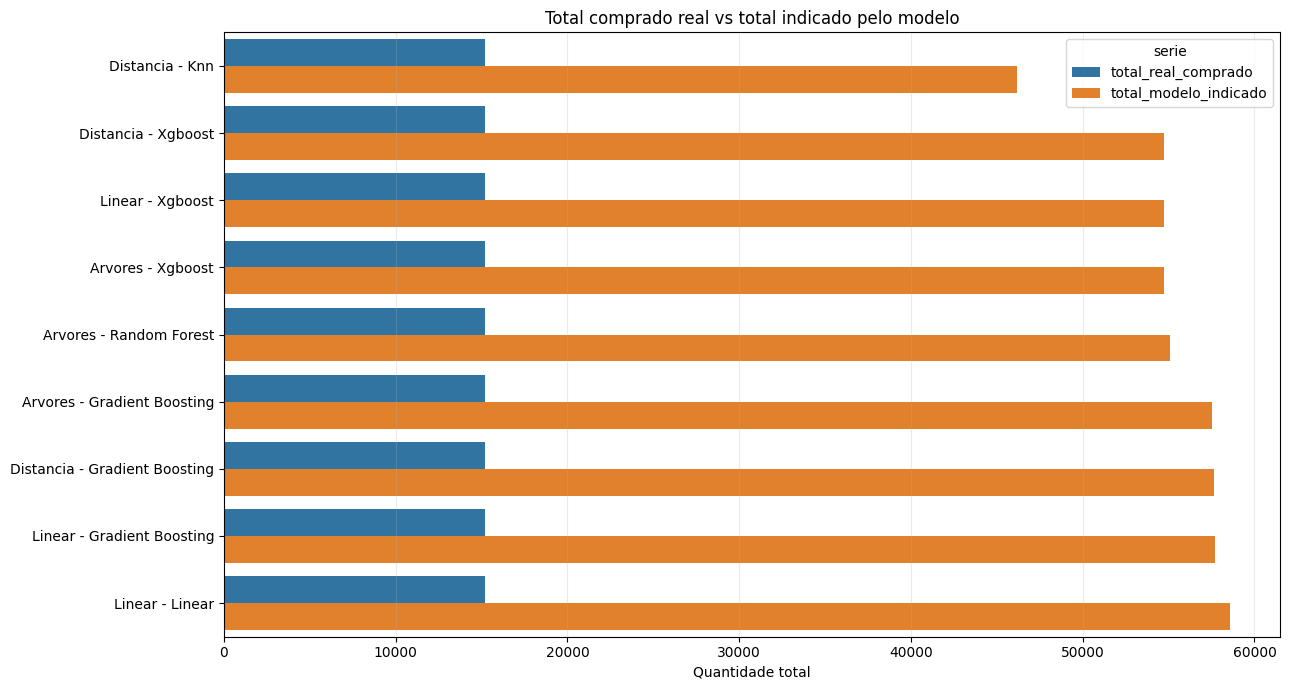

In [6]:
comparison["figures"]["operational_total_quantity"]

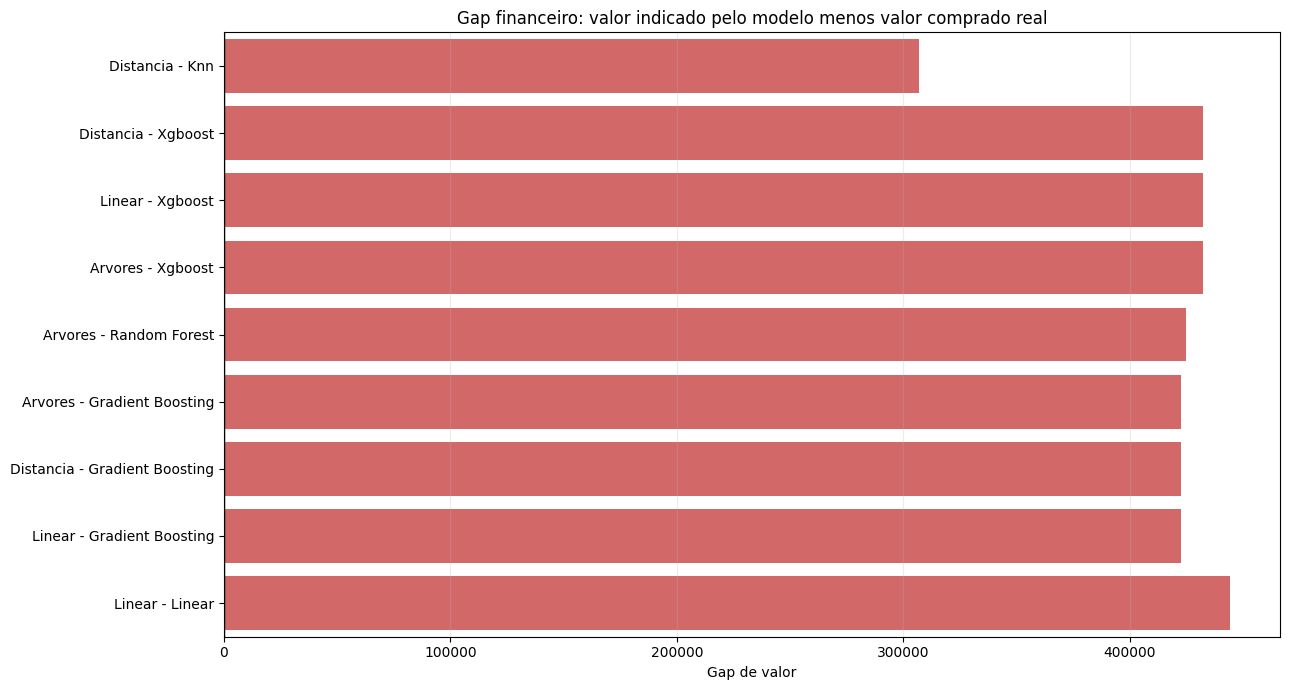

In [7]:
comparison["figures"]["operational_total_value_gap"]

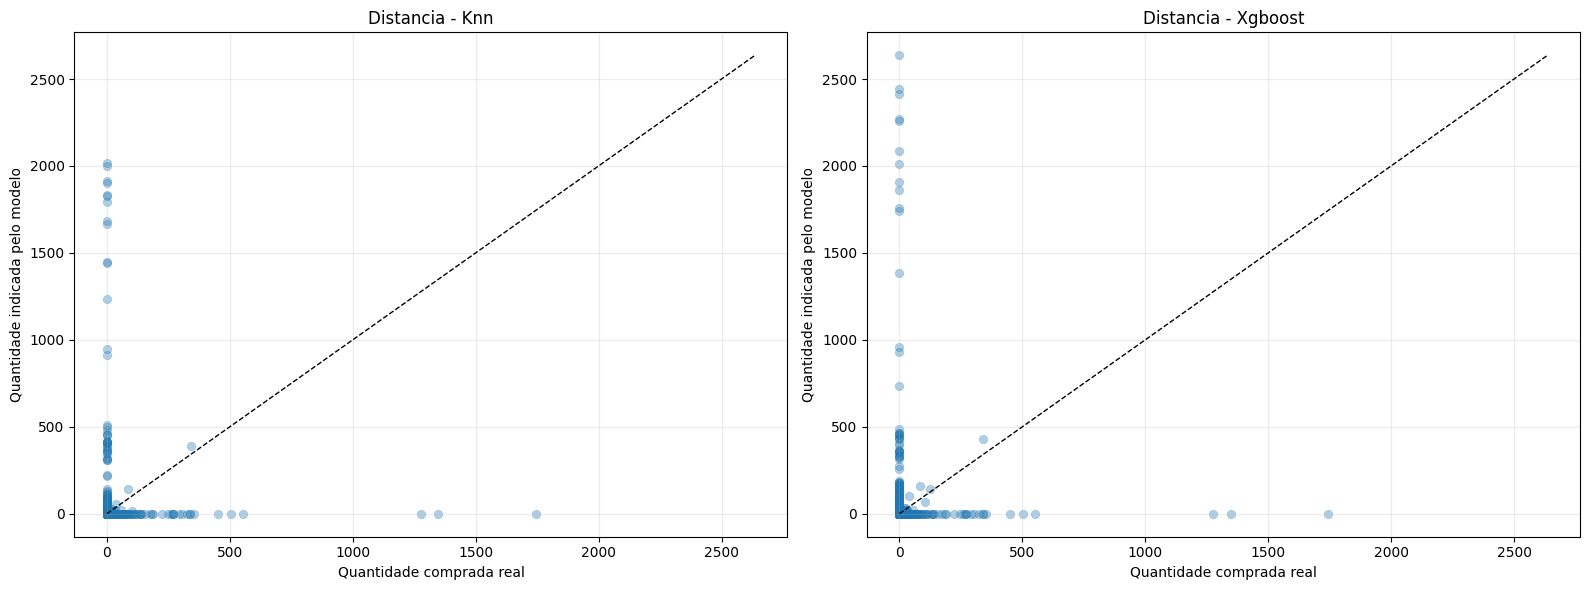

In [8]:
comparison["figures"]["operational_best_models_scatter"]

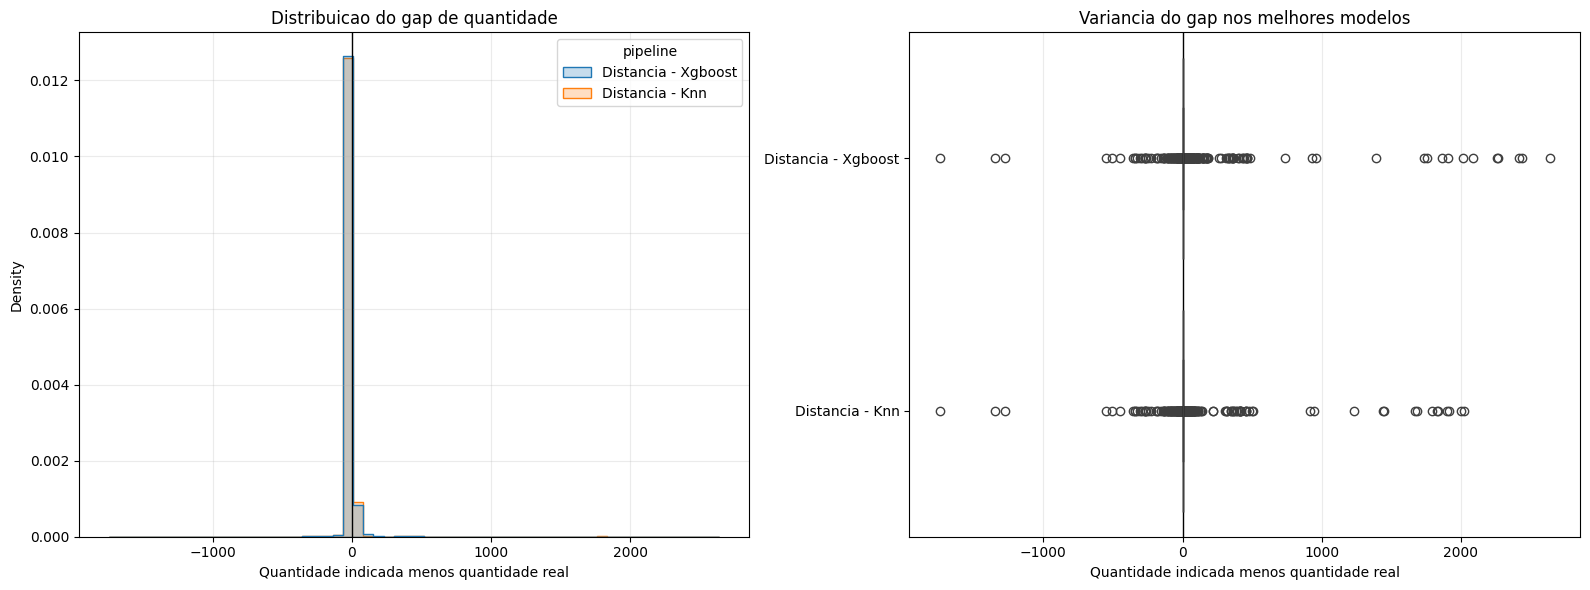

In [9]:
comparison["figures"]["operational_best_models_gap_distribution"]

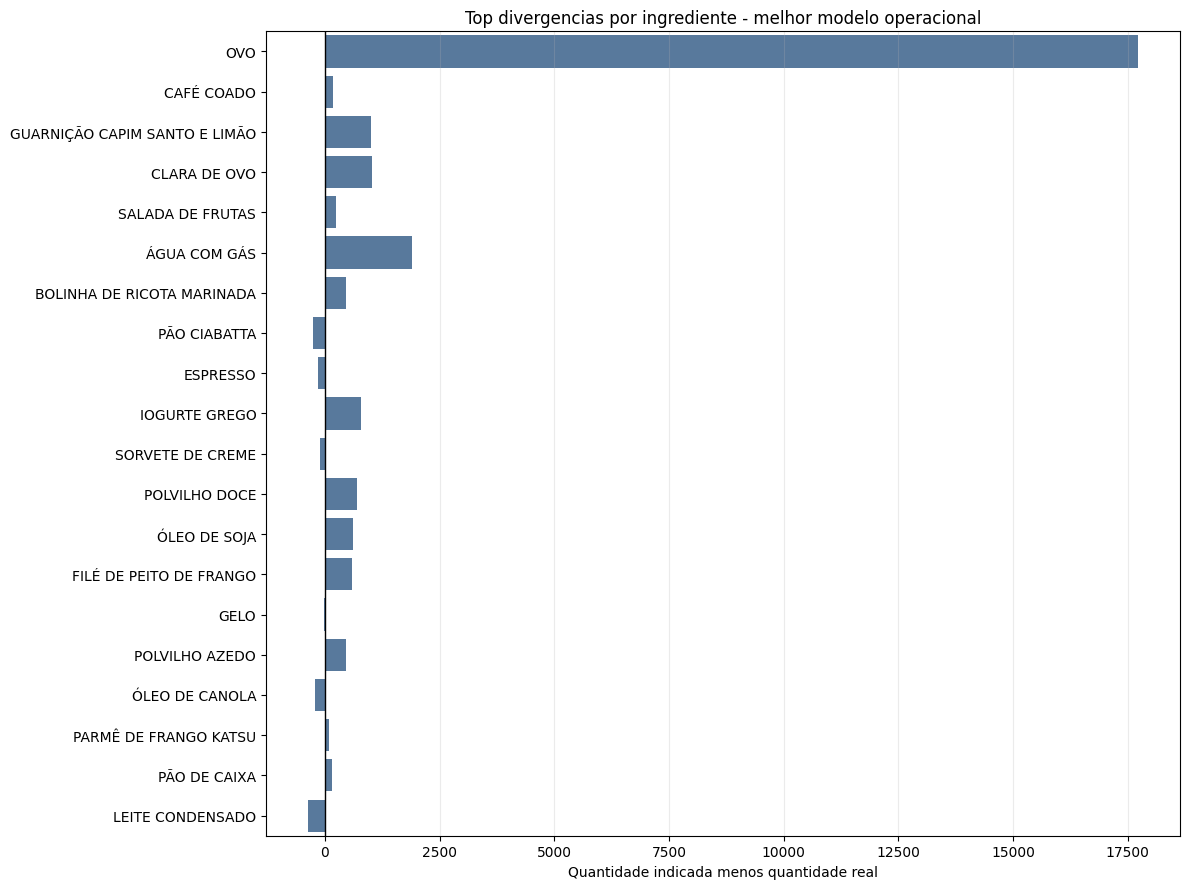

In [10]:
comparison["figures"]["operational_best_model_top_ingredient_gaps"]

## Metricas tecnicas de apoio

In [11]:
display(comparison["decision_table"])
display(comparison["classification_rank"])
display(comparison["regression_rank"])

,decision_rank,stage,stage_rank,family,model,f1_score,precision,recall,accuracy,roc_auc,rmse,mae,r2,sort_metric,artifact_path,prediction_path,warnings
0,1,classification,1,Arvores,Random Forest Classifier,0.956151,0.950939,0.961421,0.979414,0.995622,NaN,NaN,NaN,0.956151,ml/artifacts/two_stage/03_tree_ensembles_rando...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,NaN
1,2,classification,2,Distancia,Gradient Boosting Classifier,0.955515,0.950879,0.960196,0.979128,0.996355,NaN,NaN,NaN,0.955515,ml/artifacts/two_stage/01_knn_gradient_boostin...,ml/artifacts/two_stage/metrics/01_knn_gradient...,NaN
2,3,classification,3,Linear,Gradient Boosting Classifier,0.955515,0.950879,0.960196,0.979128,0.996366,NaN,NaN,NaN,0.955515,ml/artifacts/two_stage/02_linear_gradient_boos...,ml/artifacts/two_stage/metrics/02_linear_gradi...,NaN
3,4,classification,4,Arvores,Gradient Boosting Classifier,0.955515,0.950879,0.960196,0.979128,0.996366,NaN,NaN,NaN,0.955515,ml/artifacts/two_stage/03_tree_ensembles_gradi...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,NaN
4,5,classification,5,Distancia,XGBoost Classifier,0.947876,0.932977,0.963258,0.975268,0.996241,NaN,NaN,NaN,0.947876,ml/artifacts/two_stage/01_knn_xgboost_classifi...,ml/artifacts/two_stage/metrics/01_knn_xgboost_...,NaN
5,6,classification,6,Linear,XGBoost Classifier,0.947876,0.932977,0.963258,0.975268,0.996241,NaN,NaN,NaN,0.947876,ml/artifacts/two_stage/02_linear_xgboost_class...,ml/artifacts/two_stage/metrics/02_linear_xgboo...,NaN
6,7,classification,7,Arvores,XGBoost Classifier,0.947876,0.932977,0.963258,0.975268,0.996241,NaN,NaN,NaN,0.947876,ml/artifacts/two_stage/03_tree_ensembles_xgboo...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,NaN
7,8,classification,8,Distancia,KNN Classifier,0.869863,0.884737,0.855481,0.940243,0.962208,NaN,NaN,NaN,0.869863,ml/artifacts/two_stage/01_knn_knn_classifier_c...,ml/artifacts/two_stage/metrics/01_knn_knn_clas...,NaN
8,9,classification,9,Linear,Logistic Regression,0.864078,0.916266,0.817514,0.939957,0.983442,NaN,NaN,NaN,0.864078,ml/artifacts/two_stage/02_linear_logistic_regr...,ml/artifacts/two_stage/metrics/02_linear_logis...,ConvergenceWarning: lbfgs failed to converge a...
9,10,regression,1,Distancia,Gradient Boosting Regressor,NaN,NaN,NaN,NaN,NaN,70.554901,10.866622,0.900070,70.554901,ml/artifacts/two_stage/01_knn_gradient_boostin...,ml/artifacts/two_stage/metrics/01_knn_gradient...,NaN


,rank,notebook,family,stage,model,artifact_path,prediction_path,f1_score,precision,recall,accuracy,roc_auc,warnings
0,1,03_tree_ensembles,Arvores,classification,Random Forest Classifier,ml/artifacts/two_stage/03_tree_ensembles_rando...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.956151,0.950939,0.961421,0.979414,0.995622,NaN
1,2,01_knn,Distancia,classification,Gradient Boosting Classifier,ml/artifacts/two_stage/01_knn_gradient_boostin...,ml/artifacts/two_stage/metrics/01_knn_gradient...,0.955515,0.950879,0.960196,0.979128,0.996355,NaN
2,3,02_linear,Linear,classification,Gradient Boosting Classifier,ml/artifacts/two_stage/02_linear_gradient_boos...,ml/artifacts/two_stage/metrics/02_linear_gradi...,0.955515,0.950879,0.960196,0.979128,0.996366,NaN
3,4,03_tree_ensembles,Arvores,classification,Gradient Boosting Classifier,ml/artifacts/two_stage/03_tree_ensembles_gradi...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.955515,0.950879,0.960196,0.979128,0.996366,NaN
4,5,01_knn,Distancia,classification,XGBoost Classifier,ml/artifacts/two_stage/01_knn_xgboost_classifi...,ml/artifacts/two_stage/metrics/01_knn_xgboost_...,0.947876,0.932977,0.963258,0.975268,0.996241,NaN
5,6,02_linear,Linear,classification,XGBoost Classifier,ml/artifacts/two_stage/02_linear_xgboost_class...,ml/artifacts/two_stage/metrics/02_linear_xgboo...,0.947876,0.932977,0.963258,0.975268,0.996241,NaN
6,7,03_tree_ensembles,Arvores,classification,XGBoost Classifier,ml/artifacts/two_stage/03_tree_ensembles_xgboo...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.947876,0.932977,0.963258,0.975268,0.996241,NaN
7,8,01_knn,Distancia,classification,KNN Classifier,ml/artifacts/two_stage/01_knn_knn_classifier_c...,ml/artifacts/two_stage/metrics/01_knn_knn_clas...,0.869863,0.884737,0.855481,0.940243,0.962208,NaN
8,9,02_linear,Linear,classification,Logistic Regression,ml/artifacts/two_stage/02_linear_logistic_regr...,ml/artifacts/two_stage/metrics/02_linear_logis...,0.864078,0.916266,0.817514,0.939957,0.983442,ConvergenceWarning: lbfgs failed to converge a...


,rank,notebook,family,stage,model,artifact_path,prediction_path,rmse,mae,r2,warnings
0,1,01_knn,Distancia,regression,Gradient Boosting Regressor,ml/artifacts/two_stage/01_knn_gradient_boostin...,ml/artifacts/two_stage/metrics/01_knn_gradient...,70.554901,10.866622,0.900070,NaN
1,2,03_tree_ensembles,Arvores,regression,Gradient Boosting Regressor,ml/artifacts/two_stage/03_tree_ensembles_gradi...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,70.960787,10.884256,0.898917,NaN
2,3,02_linear,Linear,regression,Gradient Boosting Regressor,ml/artifacts/two_stage/02_linear_gradient_boos...,ml/artifacts/two_stage/metrics/02_linear_gradi...,71.221524,10.884353,0.898173,NaN
3,4,01_knn,Distancia,regression,XGBoost Regressor,ml/artifacts/two_stage/01_knn_xgboost_regresso...,ml/artifacts/two_stage/metrics/01_knn_xgboost_...,84.369323,11.155200,0.857107,NaN
4,5,02_linear,Linear,regression,XGBoost Regressor,ml/artifacts/two_stage/02_linear_xgboost_regre...,ml/artifacts/two_stage/metrics/02_linear_xgboo...,84.369323,11.155200,0.857107,NaN
5,6,03_tree_ensembles,Arvores,regression,XGBoost Regressor,ml/artifacts/two_stage/03_tree_ensembles_xgboo...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,84.369323,11.155200,0.857107,NaN
6,7,03_tree_ensembles,Arvores,regression,Random Forest Regressor,ml/artifacts/two_stage/03_tree_ensembles_rando...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,91.799715,12.161770,0.830830,NaN
7,8,02_linear,Linear,regression,Linear Regression,ml/artifacts/two_stage/02_linear_linear_regres...,ml/artifacts/two_stage/metrics/02_linear_linea...,91.849960,16.470480,0.830644,NaN
8,9,01_knn,Distancia,regression,KNN Regressor,ml/artifacts/two_stage/01_knn_knn_regressor_re...,ml/artifacts/two_stage/metrics/01_knn_knn_regr...,98.581844,14.787691,0.804910,NaN


## Visualizacoes tecnicas de classificacao

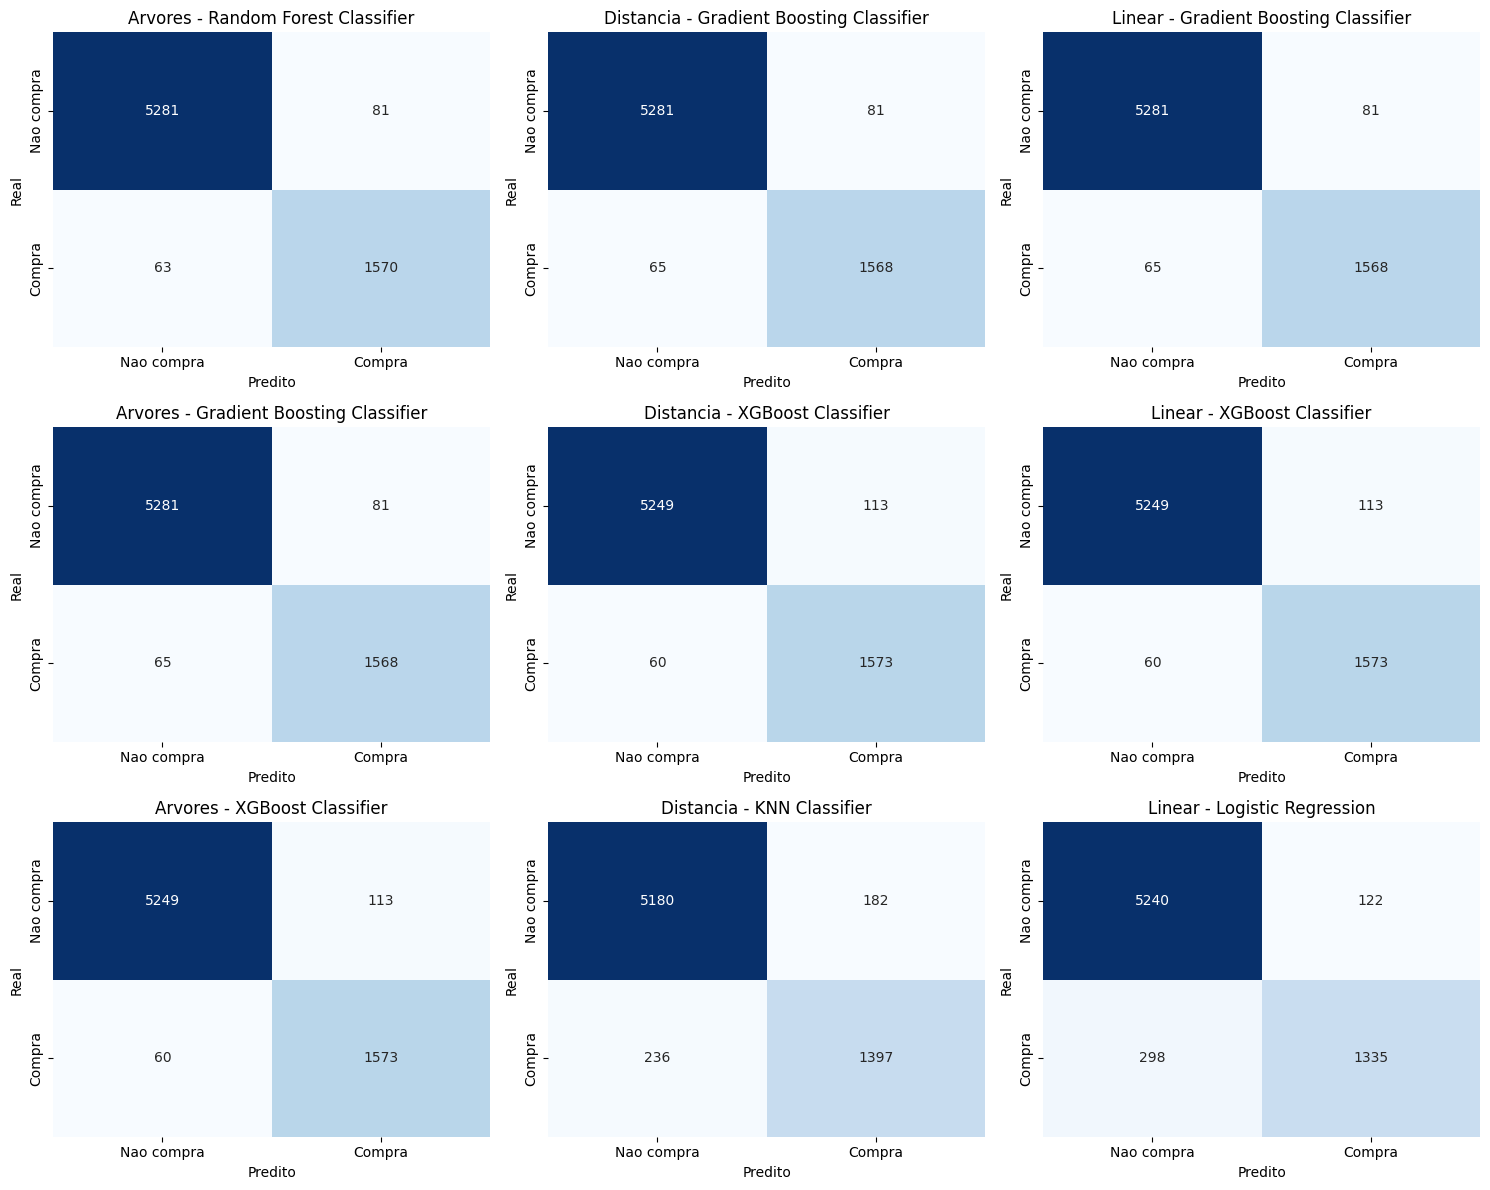

In [12]:
comparison["figures"]["confusion_matrices"]

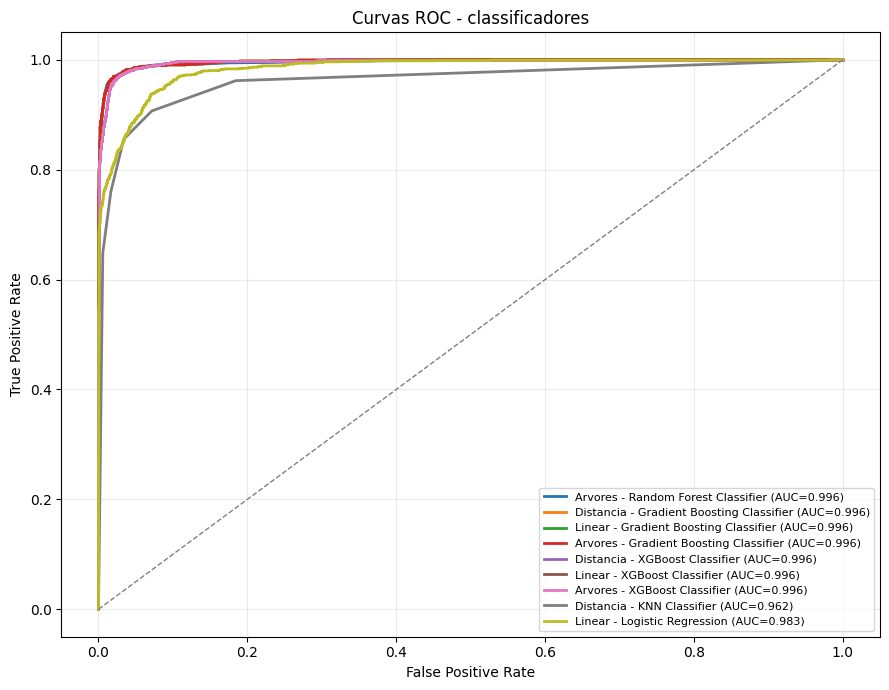

In [13]:
comparison["figures"]["roc_curves"]

## Visualizacoes tecnicas de regressao contra alvo ABT

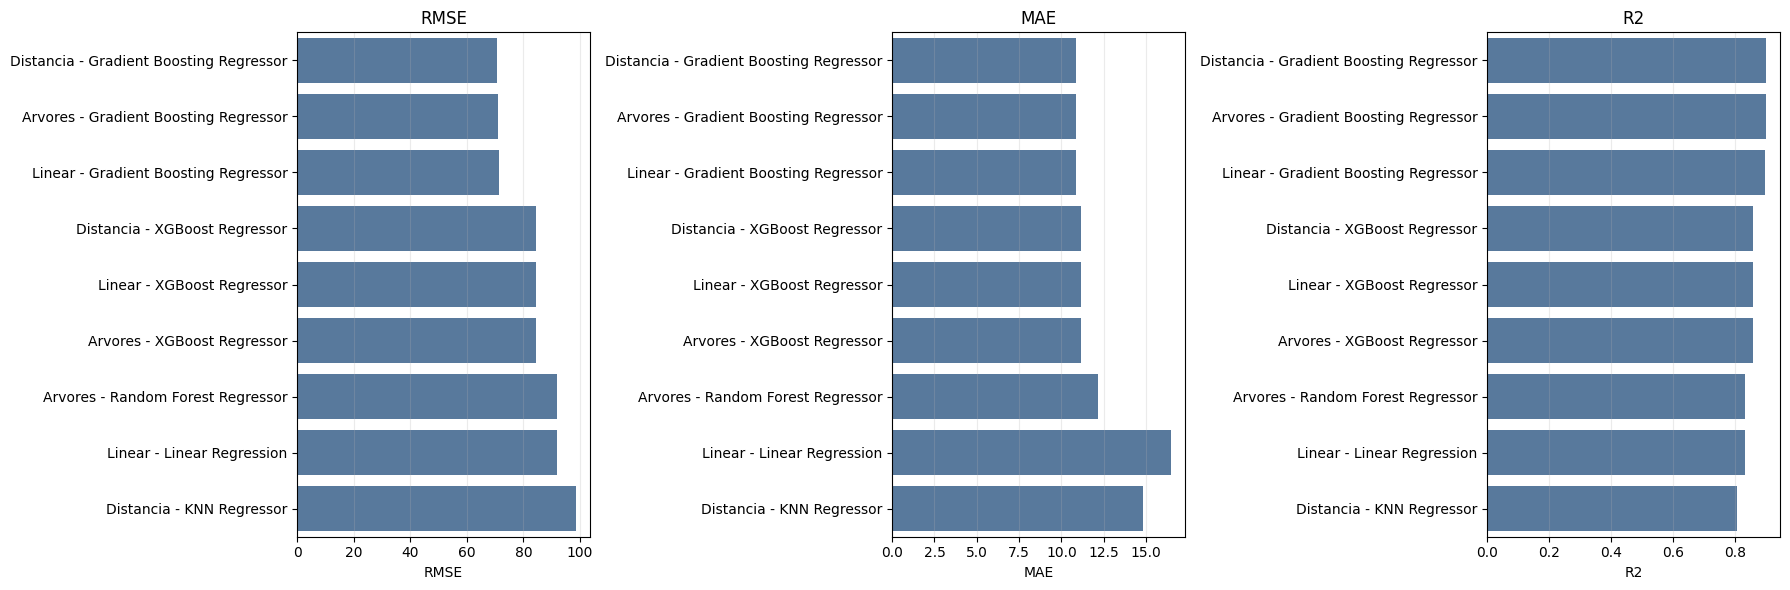

In [14]:
comparison["figures"]["regression_metric_bars"]

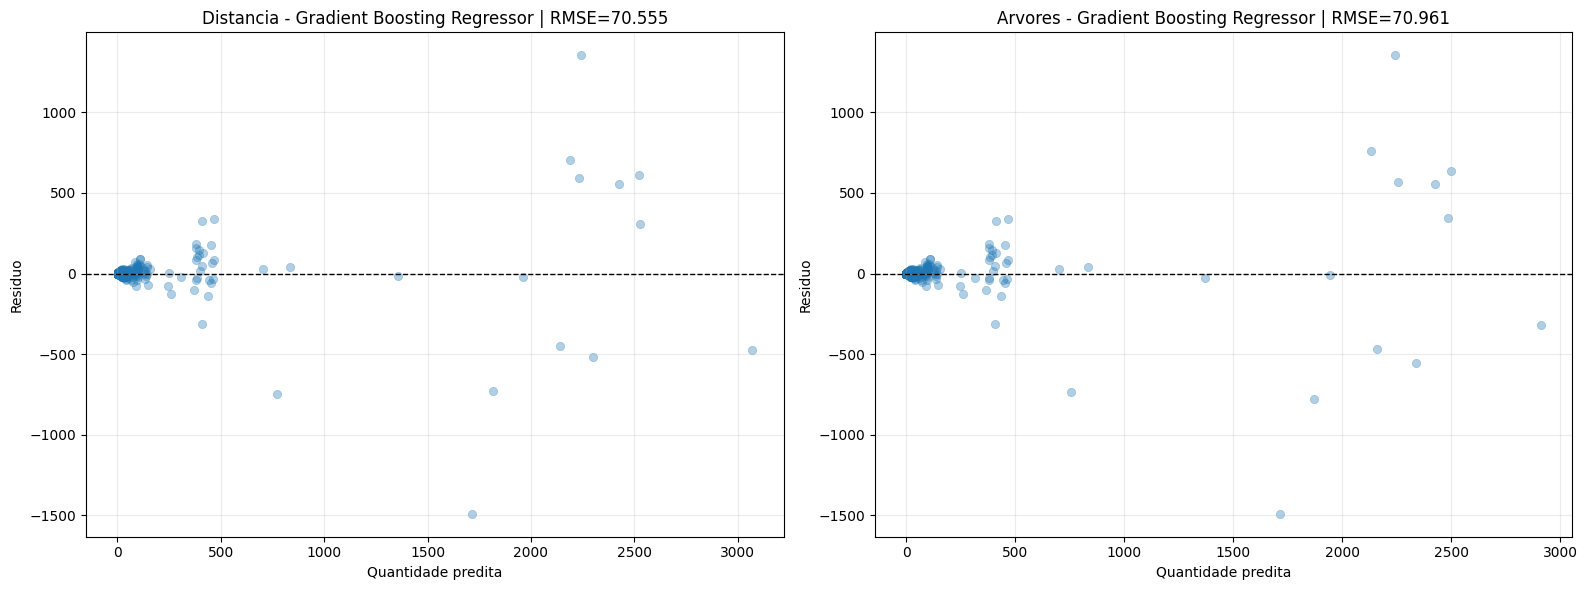

In [15]:
comparison["figures"]["top_regression_residuals"]